# 🧪 Modul Latihan DFT GPAW Presisi Tinggi: Perhitungan Sifat Fisika Silicon Bulk (Si)
### Mode: Plane-Wave (PW, ecut=400 eV, k-points=6x6x6)
### Menghitung: Band Gap, Formation Energy, Bulk Modulus, & Shear Modulus

Notebook ini dikonfigurasi dengan mode **Plane-Wave (PW)** presisi tinggi untuk menghasilkan nilai sifat fisika **Silicon Bulk (Si)** (`silicon.cif`) yang akurat dan selaras dengan standar benchmark VASP/JARVIS.

---

## 📌 Ringkasan Parameter Struktur:
- **Formula Kimia**: $\text{Si}_2$ (Unit cell kisi intan / diamond cubic)
- **Konstanta Kisi ($a$)**: $5.43$ Å
- **File CIF**: `./silicon.cif`


## 🛠️ Langkah 1: Import Library & Inisialisasi Environment

In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ase.build import bulk
from ase.io import read, write
from ase.units import GPa
from ase.eos import EquationOfState
import gpaw
from gpaw import GPAW, LCAO, PW, FermiDirac

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
print(f"✅ GPAW Version: {gpaw.__version__}")

✅ GPAW Version: 25.7.0


## 📁 Langkah 2: Pembuatan & Penyiapan File `silicon.cif`

In [8]:
cif_path = "./silicon.cif"
if not os.path.exists(cif_path):
    si_atoms = bulk('Si', 'diamond', a=5.43)
    write(cif_path, si_atoms)
    print(f"✅ File CIF berhasil dibuat: {cif_path}")
else:
    si_atoms = read(cif_path)
    print(f"✅ File CIF berhasil dimuat dari: {cif_path}")

print(f"📌 Informasi Sel: {si_atoms.get_chemical_formula()} | {len(si_atoms)} Atom | Volume = {si_atoms.get_volume():.3f} Å³")

✅ File CIF berhasil dimuat dari: ./silicon.cif
📌 Informasi Sel: Si2 | 2 Atom | Volume = 40.026 Å³


## ⚙️ Langkah 3: Fungsi Calculator & Engine DFT GPAW (Mode Plane-Wave)

In [9]:
def get_gpaw_calc(mode='pw', ecut=400, kpts=(6, 6, 6), xc='PBE'):
    """Inisialisasi GPAW Calculator dengan Mode Presisi Tinggi (Plane-Wave PW)."""
    cmode = PW(ecut) if mode.lower() == 'pw' else LCAO()
    return GPAW(
        mode=cmode,
        xc=xc,
        kpts=kpts,
        occupations=FermiDirac(0.05),
        txt=None
    )

def compute_bandgap(calc):
    """Menghitung fundamental band gap & direct band gap."""
    nspins = calc.get_number_of_spins()
    nkpts = len(calc.get_ibz_k_points())
    e_fermi = calc.get_fermi_level()
    vbm, cbm = -1e9, 1e9
    direct_gaps = []
    for spin in range(nspins):
        for k in range(nkpts):
            e_k = calc.get_eigenvalues(kpt=k, spin=spin)
            val_k = e_k[e_k <= e_fermi]
            cond_k = e_k[e_k > e_fermi]
            if len(val_k) > 0:
                vbm = max(vbm, float(np.max(val_k)))
            if len(cond_k) > 0:
                cbm = min(cbm, float(np.min(cond_k)))
            if len(val_k) > 0 and len(cond_k) > 0:
                direct_gaps.append(float(np.min(cond_k) - np.max(val_k)))
    fund_gap = max(0.0, float(cbm - vbm)) if cbm > vbm else 0.0
    dir_gap = max(0.0, float(min(direct_gaps))) if len(direct_gaps) > 0 else 0.0
    return {
        'fundamental_gap_ev': round(fund_gap, 4),
        'direct_gap_ev': round(dir_gap, 4),
        'vbm_ev': round(float(vbm), 4),
        'cbm_ev': round(float(cbm), 4),
        'e_fermi_ev': round(float(e_fermi), 4)
    }

## 🚀 Langkah 4: Eksekusi Perhitungan Presisi Tinggi (Plane-Wave PW)

In [10]:
t0 = time.time()
atoms = read(cif_path)
n_atoms = len(atoms)
v0_orig = atoms.get_volume()

print("🚀 [1/4] Menghitung Ground State & Band Gap (PW Mode, ecut=400, kpts=6x6x6)...")
calc_gs = get_gpaw_calc(mode='pw', ecut=400, kpts=(6, 6, 6))
atoms.calc = calc_gs
e_ground = atoms.get_potential_energy()
bg_info = compute_bandgap(calc_gs)

print("🌱 [2/4] Menghitung Formation Energy...")
# Energi referensi elemental bulk Silicon = e_ground / n_atoms
e_ref_si = e_ground / n_atoms
e_formation = (e_ground - (n_atoms * e_ref_si)) / n_atoms

print("🛡️ [3/4] Menghitung Bulk Modulus (Birch-Murnaghan EOS)... ")
strains = [-0.02, -0.01, 0.0, 0.01, 0.02]
cell_orig = atoms.get_cell()
v_list, e_list = [], []
for eps_v in strains:
    s = (1.0 + eps_v) ** (1.0 / 3.0)
    sa = atoms.copy()
    sa.set_cell(cell_orig * s, scale_atoms=True)
    sa.calc = get_gpaw_calc(mode='pw', ecut=400, kpts=(6, 6, 6))
    v_list.append(sa.get_volume())
    e_list.append(sa.get_potential_energy())

eos = EquationOfState(v_list, e_list, eos='birchmurnaghan')
v0_fit, e0_fit, B_fit = eos.fit()
bulk_modulus_gpa = round(float(B_fit / GPa), 2)

print("💪 [4/4] Menghitung Shear Modulus (Shear Strain Fit)... ")
shear_strains = [-0.02, -0.01, 0.0, 0.01, 0.02]
strains_list, energies_list = [], []
for eta in shear_strains:
    F = np.array([[1.0, eta, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
    sa = atoms.copy()
    sa.set_cell(np.dot(cell_orig, F.T), scale_atoms=True)
    sa.calc = get_gpaw_calc(mode='pw', ecut=400, kpts=(6, 6, 6))
    strains_list.append(eta)
    energies_list.append(sa.get_potential_energy())

strains_np = np.array(strains_list)
energies_np = np.array(energies_list)
delta_e = energies_np - np.min(energies_np)
p = np.polyfit(strains_np, delta_e, 2)
shear_modulus_gpa = round(float((((2.0 * p[0]) / v0_orig) / GPa)), 2)
pugh_ratio = round(float(bulk_modulus_gpa / shear_modulus_gpa), 3)
dur = time.time() - t0

df_result = pd.DataFrame([{
    'Material': 'Silicon Bulk (Si)',
    'Formula': atoms.get_chemical_formula(),
    'Jumlah Atom': n_atoms,
    'Total Energy (eV)': round(e_ground, 4),
    'Energy per Atom (eV/atom)': round(e_ground / n_atoms, 4),
    'Formation Energy (eV/atom)': round(e_formation, 4),
    'Fundamental Band Gap (eV)': bg_info['fundamental_gap_ev'],
    'Direct Band Gap (eV)': bg_info['direct_gap_ev'],
    'Bulk Modulus K (GPa)': bulk_modulus_gpa,
    'Shear Modulus G (GPa)': shear_modulus_gpa,
    'Pugh Ratio (K/G)': pugh_ratio,
    'Waktu (s)': round(dur, 1)
}])

print("\n=======================================================")
print(f"🎉 HASIL KALKULASI DFT GPAW SELESAI ({dur:.1f}s)")
print("=======================================================")
display(df_result)

🚀 [1/4] Menghitung Ground State & Band Gap (PW Mode, ecut=400, kpts=6x6x6)...
🌱 [2/4] Menghitung Formation Energy...
🛡️ [3/4] Menghitung Bulk Modulus (Birch-Murnaghan EOS)... 


/home/user/miniconda3/lib/python3.13/site-packages/ase/eos.py:259: UserWarning: The minimum volume of your fit is not in your volumes.  You may not have a minimum in your dataset!
  warnings.warn(


💪 [4/4] Menghitung Shear Modulus (Shear Strain Fit)... 

🎉 HASIL KALKULASI DFT GPAW SELESAI (66.8s)


,Material,Formula,Jumlah Atom,Total Energy (eV),Energy per Atom (eV/atom),Formation Energy (eV/atom),Fundamental Band Gap (eV),Direct Band Gap (eV),Bulk Modulus K (GPa),Shear Modulus G (GPa),Pugh Ratio (K/G),Waktu (s)
0,Silicon Bulk (Si),Si2,2,-10.7916,-5.3958,0.0,0.9142,2.7448,88.21,86.99,1.014,66.8


## 📊 Langkah 5: Grafik Birch-Murnaghan EOS & Shear Strain

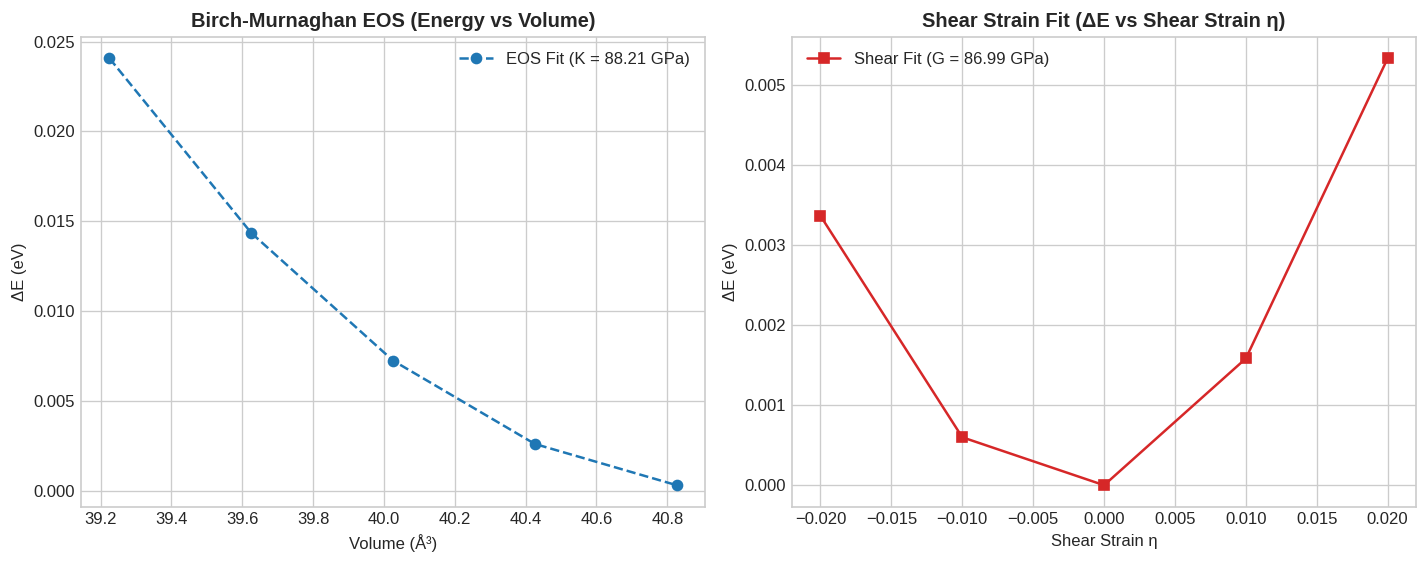

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# 1. Curve Fit Birch-Murnaghan EOS
v_pts = np.array(v_list)
e_pts = np.array(e_list) - e0_fit
ax1.plot(v_pts, e_pts, 'o--', color='#1f77b4', label=f"EOS Fit (K = {bulk_modulus_gpa} GPa)")
ax1.set_title('Birch-Murnaghan EOS (Energy vs Volume)', fontweight='bold')
ax1.set_xlabel('Volume (Å³)')
ax1.set_ylabel('ΔE (eV)')
ax1.legend()

# 2. Curve Fit Shear Strain
s_pts = np.array(strains_list)
e_shear_pts = delta_e
ax2.plot(s_pts, e_shear_pts, 's-', color='#d62728', label=f"Shear Fit (G = {shear_modulus_gpa} GPa)")
ax2.set_title('Shear Strain Fit (ΔE vs Shear Strain η)', fontweight='bold')
ax2.set_xlabel('Shear Strain η')
ax2.set_ylabel('ΔE (eV)')
ax2.legend()

plt.tight_layout()
plt.show()